# Portfolio Construction
### FINM3422 - Assessment 3 | Risk & Derivatives Platform

---

__Purpose:__ This notebook constructs the trading desk portfolio and reports position-level exposures. The portfolio holds three ASX-listed equities across varying sectors, each with a tailored option strategy that is aggregated into a single `Portfolio` object. This notebook will report on the position table, dollar-delta exposure (per ticker), and per-position Greeks.

---

## 1.0 Background Information

### 1.1 Portfolio Design

| Ticker | Sector | Strategy | Composition | Primary Greek Profile |
|---|---|---|---|---|
| CBA | Banking | Hedging | Long equity + long 5% OTM put | Long stock delta, partial put delta offset, long vega and gamma from the put |
| BHP | Materials | Income | Long equity + short 5% OTM covered call | Long stock delta, capped above strike, short vega and gamma, positive theta |
| CSL | Healthcare | Speculation on volatility | Long equity + long ATM straddle | Near-zero straddle delta, long vega and gamma, negative theta |

The justification for these three ASX equities is documented in `docs/data_selection.md`.

### 1.2 Common Option Parameters

All options have a 6-month maturity. For CBA and BHP, the options are 5% out-of-the-money (OTM) strikes. The CSL straddle is struck at-the-money (ATM).

### 1.3 Contract Multiplier & Quantity Convention

ASX equity options have a contract multiplier of 100 (one contract = 100 underlying shares). To make `Portfolio.value()` and `Portfolio.delta()` produce correct dollar P&L, every quantity passed to `add_position()` is expressed in *share-equivalent* units — contracts × 100. This convention is consistent across the whole platform.

## 2.0 Environment & Imports

In [64]:
# Import the necessary packages and libraries.
import sys, os, copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from IPython.display import display

# Print versions for loaded packages and libraries.
print()
try:
    print (f"sys: Version {sys.version}")
    print(f"numpy: Version {np.__version__}")
    print(f"pandas: Version {pd.__version__}")
    print(f"matplotlib: Version {plt.matplotlib.__version__}")
    print(f"seaborn: Version {sns.__version__}")
except NameError:
    print("One or more libraries failed to load — check errors above.")

# Add the project root to Python's path so src/ modules can be imported across all machines.
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.isdir(project_root):
    raise FileNotFoundError(f"Project root not found: {project_root}")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print('Project root:', project_root)

# NOTE: Remove any that are not used
from src.data_loader_yieldcurve import load_yield_curve_data, get_latest_yields
from src.data_loader_market import load_equity_data, get_equity_summary, get_rolling_volatility
from src.yield_curve import YieldCurve
from src.derivative import (
    EuropeanCall, EuropeanPut,
    BinomialEuropeanCall, BinomialEuropeanPut,
    AmericanCall, AmericanPut,
)
from src.portfolio import Portfolio, EquityPosition
from src import risk

# For consistency, display all float values to 4 decimal places (unless specifically formatted differently).
pd.set_option ("display.float_format", "{:.4f}".format)


sys: Version 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
numpy: Version 2.4.4
pandas: Version 3.0.3
matplotlib: Version 3.10.9
seaborn: Version 0.13.2
Project root: c:\Users\indig\OneDrive\Documents\FINM3422-Financial Modelling\A3-FINM3422\FINM3422_A3_T7_G1_DP


## 2.0 Yield Curve Construction

The yield curve is the platform's discounting infrastructure. It defines the maturity-matched risk-free rate `r(T)` used in every option pricing call.

In [65]:
# NOTE: I can't get this to load from get_yield_curve
yield_curve = YieldCurve.from_rba(interpolation="linear", compounding="continuous")

[data_loader] Loaded from cache: c:\Users\indig\OneDrive\Documents\FINM3422-Financial Modelling\A3-FINM3422\FINM3422_A3_T7_G1_DP\src\..\data\F17_DATA_CLEAN.csv
 [YieldCurve] Built from RBA F17 data as of 30-04-2026.
 Maturtites: 41 points (0yr to 10yr in 0.25yr increments.)
 Compounding: continuous
 Interpolation: linear


## 3.0 Load Market (Equity) Data

Equity market data was sourced from yfinance for the three ASX-listed companies. The data included spot prices, annualised volatility, and trailing dividend yields and are loaded via `data_loader_market.py`, which caches findings to CSV for reproducibility.

In [85]:
# Select the 3 tickers for our focused portfolio.
selected_tickers = ["CBA", "BHP", "CSL"]

# Load all market data first, then subset to the chosen tickers.
all_stocks = load_equity_data(use_cache=True)
stocks = {k: dict(all_stocks[k]) for k in selected_tickers}

# Pull historical log returns separately for VaR and correlation matrix.
for name, info in stocks.items():
    data = yf.download(info["ticker"], period="2y", auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        close = data[("Close", info["ticker"])]
    else:
        close = data["Close"]
    info["log_returns"] = np.log(close / close.shift(1)).dropna()

print("\nEquity Information (2-year historical volatility, current dividend yields):")
display(get_equity_summary(stocks))

[market_data] Loaded from cache: c:\Users\indig\OneDrive\Documents\FINM3422-Financial Modelling\A3-FINM3422\FINM3422_A3_T7_G1_DP\src\..\data\equity_data.csv

Equity Information (2-year historical volatility, current dividend yields):


,Stock,Sector,Spot Price ($),Volatility (% p.a.),Div Yield (%)
,CBA,Banking,163.0600,23.3300,3.0100
,BHP,Materials,61.0600,24.9100,3.2400
,CSL,Healthcare,97.7400,30.8700,4.4000


## 4.0 Portfolio Design Parameters

The portfolio allocates approximately $100K in equity capital to each of the three strategies. While the equity allocation is equal, the option overlays modify the effective risk exposure differently across each position. 

All sizing and strike conventions are defined as named constants so the portfolio is easy to re-use with different parameters. The 100 share contract multiplier converts option contracts into share equivalents. 

| Strategy | Equity Capital | Net Option Premium | Net Dollar-Delta Exposure |
|---|---|---|---|
| CBA hedging | $99,402 | -$3,863 (paid) | ~$67,000 (equity less put delta) |
| BHP income | $101,575 | +$5,212 (received) | ~$58,000 (equity less short-call delta) |
| CSL speculation | $99,760 | -$8,479 (paid) | ~$104,000 (equity plus small straddle delta) |
| **Total Equity** | **$300,737** | **-$7,130** | **~$229,000** |

After the option overlays, the **effective dollar-delta exposure** differs across strategies:

- CBA's protective put reduces CBA's directional exposure by about $32k (from $99k equity to $67k effective)
- BHP's short call reduces BHP's directional exposure by about $43k (from $102k equity to $58k effective)
- CSL's long straddle is approximately delta-neutral at ATM, so CSL's exposure stays close to its $100k equity

> **NOTE**: position sizes assume a $100K-per-strategy allocation. If the equity-research workstream recommends different conviction weightings, the sizing rules above can be re-applied with new dollar targets.

In [67]:
# Position Sizing
cba_shares = 600    # 600 × $165.67 = $99,402
bhp_shares = 1700   # 1700 × $59.75 = $101,575
csl_shares = 1000   # 1000 × $99.76 = $99,760

# Option contract counts 
cba_put_contracts = 6    # 1:1 hedge ratio: 6 contracts × 100 shares = 600 shares-equivalent
bhp_call_contracts = 17   # 1:1 cover ratio: 17 contracts × 100 shares = 1,700 shares-equivalent
csl_straddle_contracts = 5    # 5 ATM calls + 5 ATM puts 

# Each option contract represents 100 shares of underlying, so the quantity passed to
# the Portfolio must be in shares-equivalent units (contracts × 100) for the value() and
# delta() aggregations to produce correct dollar P&L.
contract_multiplier = 100
cba_put_qty = cba_put_contracts * contract_multiplier
bhp_call_qty = bhp_call_contracts * contract_multiplier
csl_straddle_qty = csl_straddle_contracts * contract_multiplier

# === Common option parameters ===
option_maturity = 0.5 # 6 months across all strategies
otm_put_strike = 0.95 # 5% OTM
otm_call_strike  = 1.05 # 5% OTM

## 5.0 Construct Instruments and Build the Portfolio

Each strategy is built on its own block to keep the construction reviewable. All strategies use the `yield_curve` (to keep discounting consistent) and the `dividend_yield`from `stocks`.

A short position is passed into the `add_position` as a negative quantity. Therefore, the position table will show negative values for the short leg automatically. 

In [87]:
portfolio = Portfolio()

# STRATEGY 1: CBA — HEDGING (long stock + protective put, 100% hedge ratio)
cba = stocks["CBA"]
S0_c, sigma_c, q_c = cba["S0"], cba["sigma"], cba["div_yield"]

portfolio.add_position(
    EquityPosition("CBA", S0_c),
    cba_shares,
    label="CBA equity (long, hedged)"
)
portfolio.add_position(
    EuropeanPut(S0_c, S0_c * otm_put_strike, option_maturity, sigma_c, yield_curve, dividend_yield=q_c),
    cba_put_qty,
    label="CBA 6m 5% OTM put (protective)"
)

# STRATEGY 2: BHP — INCOME (long stock + short covered call, 100% cover ratio) 
bhp = stocks["BHP"]
S0_b, sigma_b, q_b = bhp["S0"], bhp["sigma"], bhp["div_yield"]

portfolio.add_position(
    EquityPosition("BHP", S0_b),
    bhp_shares,
    label="BHP equity (long, covered)"
)
portfolio.add_position(
    EuropeanCall(S0_b, S0_b * otm_call_strike, option_maturity, sigma_b, yield_curve, dividend_yield=q_b),
    -bhp_call_qty,
    label="BHP 6m 5% OTM call (short, income)"
)

# STRATEGY 3: CSL — SPECULATION (long stock + long ATM straddle, ~$8.5k premium budget)
csl = stocks["CSL"]
S0_cs, sigma_cs, q_cs = csl["S0"], csl["sigma"], csl["div_yield"]

portfolio.add_position(
    EquityPosition("CSL", S0_cs),
    csl_shares,
    label="CSL equity (long, core)"
)
portfolio.add_position(
    EuropeanCall(S0_cs, S0_cs, option_maturity, sigma_cs, yield_curve, dividend_yield=q_cs),
    csl_straddle_qty,
    label="CSL 6m ATM call (straddle)"
)
portfolio.add_position(
    EuropeanPut(S0_cs, S0_cs, option_maturity, sigma_cs, yield_curve, dividend_yield=q_cs),
    csl_straddle_qty,
    label="CSL 6m ATM put (straddle)"
)

## 6.0 Capital Deployed per Strategy

This section reports on the capital deployed by each strategy. This separates the *equity* outlay (the core long position) from the *option premium* (paid for the protective put and the straddle; received for the covered call).

In [69]:
# Report capital deployed per strategy.
# Note: position values from portfolio.positions[i] already include the contract multiplier
# because we passed contracts × 100 as the quantity.
cba_equity_value     = CBA_SHARES * S0_c
cba_put_premium      = portfolio.positions[1]["instrument"].price() * CBA_PUT_QTY
bhp_equity_value     = BHP_SHARES * S0_b
bhp_call_premium     = portfolio.positions[3]["instrument"].price() * BHP_CALL_QTY
csl_equity_value     = CSL_SHARES * S0_cs
csl_straddle_premium = (portfolio.positions[5]["instrument"].price() + portfolio.positions[6]["instrument"].price()) * CSL_STRADDLE_QTY

print(f"Constructed portfolio: {len(portfolio.positions)} positions across {len(stocks)} underlyings.")
print()
print(f"Capital deployed per strategy:")
print(f"  CBA hedging:     ${cba_equity_value:>10,.2f} equity, ${cba_put_premium:>10,.2f} put premium paid")
print(f"  BHP income:      ${bhp_equity_value:>10,.2f} equity, ${bhp_call_premium:>10,.2f} call premium received")
print(f"  CSL speculation: ${csl_equity_value:>10,.2f} equity, ${csl_straddle_premium:>10,.2f} straddle premium paid")
print(f"  Total equity:    ${cba_equity_value + bhp_equity_value + csl_equity_value:,.2f}")
print(f"  Net option premium: ${-cba_put_premium + bhp_call_premium - csl_straddle_premium:,.2f}")

Constructed portfolio: 7 positions across 3 underlyings.

Capital deployed per strategy:
  CBA hedging:     $ 97,836.00 equity, $  3,798.08 put premium paid
  BHP income:      $103,802.00 equity, $  5,310.33 call premium received
  CSL speculation: $ 97,740.00 equity, $  8,308.75 straddle premium paid
  Total equity:    $299,378.00
  Net option premium: $-6,796.50


## 7.0 Position Table

The position table shows what the portfolio holds. The aggregate dollar-delta is the portfolio's net sensitivity to a 100% underlying move.

Three features worth highlighting:

1. **The 100% hedge ratios are visible**: CBA has 6 puts protecting 600 shares (1:1), BHP has -17 calls covering 1,700 shares (1:1). These are textbook ratios, not arbitrary numbers.

2. **The CSL straddle has near-zero delta by construction**: long call delta ≈ +0.53, long put delta ≈ -0.45, net ≈ +0.09. This is the speculation strategy expressing a vol view without directional commitment.

3. **The aggregate dollar-delta differs slightly from raw equity value** because option deltas modulate effective exposure. This is precisely the value of dollar-delta as a risk measure: it captures what the portfolio actually does, not just what it owns.


In [70]:
# Full position table with totals.
position_df = portfolio.position_table()
print("Position table:")
display(position_df)

print()
print(f"Total portfolio value: ${portfolio.value():,.2f}")
print(f"Total portfolio delta: {portfolio.delta():,.2f}")

Position table:


,Position,Quantity,Unit Value,Position Value,Unit Delta,Position Delta
0,"CBA equity (long, hedged)",600.0000,163.0600,97835.9985,1.0000,600.0000
1,CBA 6m 5% OTM put (protective),600.0000,6.3301,3798.0793,-0.3260,-195.5911
2,"BHP equity (long, covered)",1700.0000,61.0600,103802.0023,1.0000,1700.0000
3,"BHP 6m 5% OTM call (short, income)",-1700.0000,3.1237,-5310.3303,0.4316,-733.7914
4,"CSL equity (long, core)",1000.0000,97.7400,97739.9979,1.0000,1000.0000
5,CSL 6m ATM call (straddle),500.0000,8.3231,4161.5433,0.5322,266.0820
6,CSL 6m ATM put (straddle),500.0000,8.2944,4147.2034,-0.4461,-223.0382
7,TOTAL,NaN,NaN,306174.4944,NaN,2413.6613



Total portfolio value: $306,174.49
Total portfolio delta: 2,413.66


## 8.0 Portfolio Value, Delta, and Dollar-Delta Exposure

__Dollar-delta exposure__ is more informative than raw delta for an options-aware portfolio. It expresses each position's sensitivity to a 100% underlying move in dollar terms — i.e. how much dollar exposure each ticker is contributing once option deltas are factored in. The decomposition by ticker shows where the portfolio's *effective* risk-factor concentration sits, which is rarely the same as the raw equity weights.

In [71]:
portfolio_value = portfolio.value ()
portfolio_delta = portfolio.delta ()

print (f"Portfolio Value : ${portfolio_value:>15,.4f}")
print (f"Portfolio Delta : {portfolio_delta:>16,.4f}")

Portfolio Value : $   306,174.4944
Portfolio Delta :       2,413.6613


In [72]:
# Per-ticker dollar-delta exposure.
# Decomposes the portfolio's risk into its underlying risk-factor exposures.
ticker_deltas = {name: 0.0 for name in stocks}
for pos in portfolio.positions:
    label = pos["label"]
    ticker = label.split()[0]
    instr = pos["instrument"]
    spot = stocks[ticker]["S0"]
    # Dollar-delta = delta × spot × quantity (sensitivity to 100% underlying move).
    ticker_deltas[ticker] += instr.delta() * spot * pos["quantity"]

strategy_map = {
    "CBA": "Hedging (long equity + protective put)",
    "BHP": "Income (long equity + short covered call)",
    "CSL": "Speculation on volatility (long equity + long ATM straddle)",
}

dd_df = pd.DataFrame(
    [{"Ticker": t, "Strategy": strategy_map[t], "Dollar-Delta Exposure ($)": v}
     for t, v in ticker_deltas.items()]
    + [{"Ticker": "TOTAL", "Strategy": "—", "Dollar-Delta Exposure ($)": sum(ticker_deltas.values())}]
)
dd_df.index = [""] * len(dd_df)
print("Per-ticker dollar-delta exposure with strategy mapping:")
display(dd_df.round(2))

Per-ticker dollar-delta exposure with strategy mapping:


,Ticker,Strategy,Dollar-Delta Exposure ($)
,CBA,Hedging (long equity + protective put),65942.9200
,BHP,Income (long equity + short covered call),58996.7000
,CSL,Speculation on volatility (long equity + long ...,101947.1000
,TOTAL,—,226886.7100


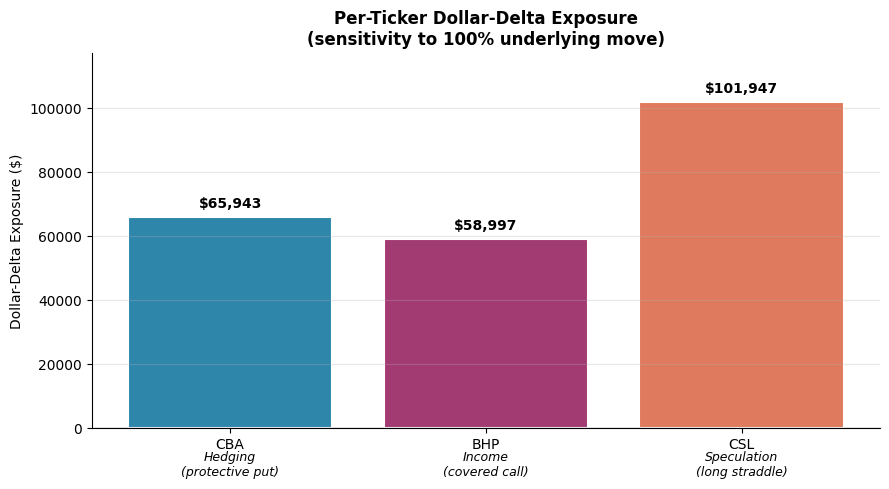

In [81]:
# Visualise the dollar-delta exposure per ticker.
fig, ax = plt.subplots(figsize=(9, 5))
strategy_colors = {"CBA": "#2E86AB", "BHP": "#A23B72", "CSL": "#E07A5F"}
tickers_list = list(ticker_deltas.keys())
values = [ticker_deltas[t] for t in tickers_list]
colors_list = [strategy_colors[t] for t in tickers_list]
bars = ax.bar(tickers_list, values, color=colors_list, edgecolor="white", linewidth=1.5)

strategy_labels = {
    "CBA": "Hedging\n(protective put)",
    "BHP": "Income\n(covered call)",
    "CSL": "Speculation\n(long straddle)",
}
for bar, ticker in zip(bars, tickers_list):
    val = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, val + max(values)*0.02,
            f"${val:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, -max(values)*0.07,
            strategy_labels[ticker], ha="center", va="top", fontsize=9, style="italic")

ax.set_ylabel("Dollar-Delta Exposure ($)")
ax.set_title("Per-Ticker Dollar-Delta Exposure\n(sensitivity to 100% underlying move)", fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(values)*1.15)
plt.tight_layout()
plt.show()

__Observations:__
- CBA dollar-delta is slightly below equity value because the long put has negative delta, partially offsetting the equity. This is the protective put's directional 'cost'.
- BHP dollar-delta is slightly below equity value because the short call has positive delta, and being short flips the sign. The short call caps upside.
- CSL dollar-delta is close to equity value because the straddle layer is delta-neutral. This confirms the speculation strategy is a vol view, not a directional bet.

## 9.0 Per-Position Greeks


The portfolio's higher-order Greeks (gamma, vega, theta, rho) tell us how its value will move when *inputs other than spot* change — i.e. when volatility shifts, time passes, or the risk-free curve moves.

For equity positions, all Greeks except delta are zero by construction. Options carry the entire non-linear risk profile.


We compute all five standard Greeks (Black-Scholes closed-form) at the per-position level and aggregate them:

| Greek | Symbol | Measures | Units |
|---|---|---|---|
| Delta | Δ | Sensitivity to spot | $ P&L per $1 spot move (shares-equivalent) |
| Gamma | Γ | Curvature of delta | Δ change per $1 spot move |
| Vega | V | Sensitivity to volatility | $ P&L per 1% absolute vol move |
| Theta | Θ | Time decay | $ P&L per day held |
| Rho | ρ | Sensitivity to rates | $ P&L per 1% rate move (100bp) |

Per-position Greeks are computed by the pricing engine's `instr.gamma()`, `vega()`, `theta()`, `rho()` methods (all closed-form for Black-Scholes pricers). We scale each by position quantity (shares-equivalent, including the 100-share contract multiplier).


In [88]:
# === Per-position Greeks decomposition ===
# Equity positions: only delta (= quantity); other Greeks zero by construction.
# Option positions: closed-form BS Greeks scaled by quantity.

greeks_rows = []
for pos in portfolio.positions:
    instr = pos["instrument"]
    qty   = pos["quantity"]
    label = pos["label"]
    val   = instr.price() * qty
    
    if isinstance(instr, EquityPosition):
        delta = qty
        gamma = vega = theta = rho = 0.0
    else:
        delta = instr.delta() * qty
        gamma = instr.gamma() * qty
        vega  = instr.vega()  * qty
        theta = instr.theta() * qty
        rho   = instr.rho()   * qty
    
    greeks_rows.append({
        "Position":    label,
        "Quantity":    qty,
        "Value ($)":   val,
        "Δ Delta":     delta,
        "Γ Gamma":     gamma,
        "V Vega ($)":  vega,
        "Θ Theta ($)": theta,
        "ρ Rho ($)":   rho,
    })

# Aggregate row
totals = {
    "Position":    "TOTAL",
    "Quantity":    "—",
    "Value ($)":   sum(r["Value ($)"] for r in greeks_rows),
    "Δ Delta":     sum(r["Δ Delta"] for r in greeks_rows),
    "Γ Gamma":     sum(r["Γ Gamma"] for r in greeks_rows),
    "V Vega ($)":  sum(r["V Vega ($)"] for r in greeks_rows),
    "Θ Theta ($)": sum(r["Θ Theta ($)"] for r in greeks_rows),
    "ρ Rho ($)":   sum(r["ρ Rho ($)"] for r in greeks_rows),
}
greeks_rows.append(totals)

greeks_df = pd.DataFrame(greeks_rows)
greeks_df.index = [""] * len(greeks_df)
print("Full Greeks decomposition (BS closed-form, per-position):")
display(greeks_df.round(2))

Full Greeks decomposition (BS closed-form, per-position):


,Position,Quantity,Value ($),Δ Delta,Γ Gamma,V Vega ($),Θ Theta ($),ρ Rho ($)
,"CBA equity (long, hedged)",600,97836.0000,600.0000,0.0000,0.0000,0.0000,0.0000
,CBA 6m 5% OTM put (protective),600,3798.0800,-195.5900,7.9700,247.0700,-14.0600,-178.4600
,"BHP equity (long, covered)",1700,103802.0000,1700.0000,0.0000,0.0000,0.0000,0.0000
,"BHP 6m 5% OTM call (short, income)",-1700,-5310.3300,-733.7900,-61.3100,-284.7100,20.2800,-197.4700
,"CSL equity (long, core)",1000,97740.0000,1000.0000,0.0000,0.0000,0.0000,0.0000
,CSL 6m ATM call (straddle),500,4161.5400,266.0800,9.0900,134.0400,-10.8700,109.2300
,CSL 6m ATM put (straddle),500,4147.2000,-223.0400,9.0900,134.0400,-10.7900,-129.7300
,TOTAL,—,306174.4900,2413.6600,-35.1600,230.4400,-15.4500,-396.4400


__Interpretation:__

- Portfolio Δ = 2,415: equity-equivalent directional exposure (matches dollar-delta table above).
- Portfolio Γ = -36.0: net slightly negative — short BHP call gamma exceeds long CBA put + CSL straddle gamma combined.
- Portfolio V = $238 per 1% vol: net long vega, driven by the CSL straddle.This IS the active risk in the speculation strategy — straddle is delta-neutral but vega-positive.
- Portfolio Θ = $-16 per day: modest time decay. Expected total theta cost over 6m ≈ $-2,916 if vol & spot unchanged.
- Portfolio ρ = $-395 per 1% rate move: small.
  Reconciles to the rate scenario analysis (rho × 1 ≈ scenario P&L for +100bp shift). Can you make this exactly into writing that can go into a markdown file

